
# Machine Learning Modelling

### Recap

### **Problem Statement**

This project aims to analyze the effectiveness of direct marketing campaigns and identify key factors that influence customers' decisions to subscribe to a long-term deposit. The study seeks to uncover patterns that can help optimize future marketing strategies and improve campaign success rates.

### **Hypothesis**

Clients with higher `account balances` (above average), no `personal loans`, longer `last-contact durations` with the bank marketing agent, and a successful `outcome in previous campaigns` are more likely to subscribe to a `term deposit` than other clients.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# LIBRARIES
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import pearsonr
from sklearn.cluster import KMeans

In [ ]:
warnings.filterwarnings('ignore')

# input_directory = "/content/drive/MyDrive/FALL 2025/Applied Data Science/Bank Dataset/"
# input_directory = "/content/drive/MyDrive/GROUP_1/Bank Dataset/"
input_directory = "/content/drive/MyDrive/Applied Data Science/Python_DataSet/Bank Dataset/"


df = pd.read_csv(input_directory + "preprocessed_bank_dataset.csv")

df.head(5)

,age,job,marital,education,default,balance,housing_loan,personal_loan,contact,day,...,pdays,previous,poutcome,y,high_balance,long_duration,prev_success,no_loans,hypothesis_group,duration_log
0,58,management,2,2,0,2143,1,0,0,5,...,-1,0,0,0,1,1,0,0,0,5.5683
1,44,technician,0,1,0,29,1,0,0,5,...,-1,0,0,0,0,0,0,0,0,5.0239
2,33,entrepreneur,2,1,0,2,1,1,0,5,...,-1,0,0,0,0,0,0,0,0,4.3438
3,47,blue-collar,2,1,0,1506,1,0,0,5,...,-1,0,0,0,1,0,0,0,0,4.5326
4,33,blue-collar,0,1,0,1,0,0,0,5,...,-1,0,0,0,0,0,0,1,0,5.2933


## **Context and Feature Definition**

**Identifying and Understanding Relevant/Informative Features**

In this part, we seek to understand three main aspects that guide our exploration of the dataset and help validate our hypothesis:

- **Variables that directly affect the outcome** — explicitly mentioned in the hypothesis and expected to influence the likelihood of subscribing to a term deposit.  
- **Variables that can be inferred to affect the outcome** — not directly stated but logically derived from the dataset to represent underlying factors like financial stability or engagement.  
- **Control variables** — capture demographic and socio-economic differences that may influence decisions - they can provide useful subgroup insights or serve as control variables in later analyses.



**Outcome Variable**
- `y` — whether the client subscribed to a term deposit (`yes` / `no`)



**Directly Related Variables**
- `balance` — higher account balances indicate greater financial capacity, making it more feasible for clients to invest in term deposits.  
- `loan` — clients without personal loans have fewer financial obligations, increasing their ability to allocate funds toward term deposits.  
- `duration` — longer last-contact durations suggest higher engagement or interest during the campaign conversation, reflecting a stronger likelihood of subscription.  
- `poutcome` — a successful outcome in a previous campaign signals prior interest in the bank’s products, indicating that the client may be receptive to subscribing again.


**Inferred Variables**
- **Financial stability:** `housing`, `default`, `job`, `education`  
- **Engagement level:** `campaign`, `pdays`, `contact`, `previous`  
- **Trust/responsiveness:** inferred from `duration`, `poutcome`, `contact`



**Control Variables**
- `age`, `marital`, `education`, `job` — capture demographic and socio-economic differences that may influence decisions - they can provide useful subgroup insights or serve as control variables in later analyses.


## **Extended Exploratory Data Analysis (Milestone 3)**

Our EDA in this milestone is structured to move from broad patterns to
hypothesis-driven exploration and finally to modeling prerequisites:

1. Start with the overall target distribution (class imbalance).
2. Compare subscribers vs non-subscribers on key predictors.
3. Examine distributions and correlations of important features.
4. Diagnose multicollinearity and (non-)linearity for modeling.
5. Explore interaction effects suggested by our instructor.
6. Summarize which features are “model-ready” and how they should enter.

This way, each plot or table has a clear purpose: it either explains the data
or directly informs a modeling decision.

In [ ]:
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (7.5, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Ensure target variable is numeric
if df["y"].dtype == object:
    df["y"] = df["y"].map({"no": 0, "yes": 1}).astype(int)

# Reconstruct engineered features if missing
if "high_balance" not in df.columns:
    df["high_balance"] = (df["balance"] > df["balance"].mean()).astype(int)

if "long_duration" not in df.columns:
    df["long_duration"] = (df["duration"] > df["duration"].mean()).astype(int)

if "prev_success" not in df.columns:
    if "poutcome" in df.columns:
        if df["poutcome"].dtype == object:
            df["prev_success"] = (df["poutcome"].str.lower() == "success").astype(int)
        else:
            df["prev_success"] = (df["poutcome"] == 3).astype(int)
    else:
        df["prev_success"] = 0  # fallback

if "no_loans" not in df.columns:
    loan_cols = [col for col in df.columns if "loan" in col.lower()]
    df["no_loans"] = (df[loan_cols].apply(lambda row: (row == "no").sum(), axis=1) == len(loan_cols)).astype(int)

if "hypothesis_group" not in df.columns:
    df["hypothesis_group"] = (
        df["high_balance"] &
        df["long_duration"] &
        df["prev_success"] &
        df["no_loans"]
    ).astype(int)

print("Extended EDA setup complete ✓")

Extended EDA setup complete ✓


### 0. Target Imbalance (y)

We begin by looking at the overall distribution of the target variable.
If one class dominates (for example, "no subscription"), then a high accuracy
score can be misleading, and we need to rely on metrics like precision and
recall instead.


Raw counts:
 y
0    39922
1     5289
Name: count, dtype: int64

Percentages:
 y
0    88.3
1    11.7
Name: proportion, dtype: float64


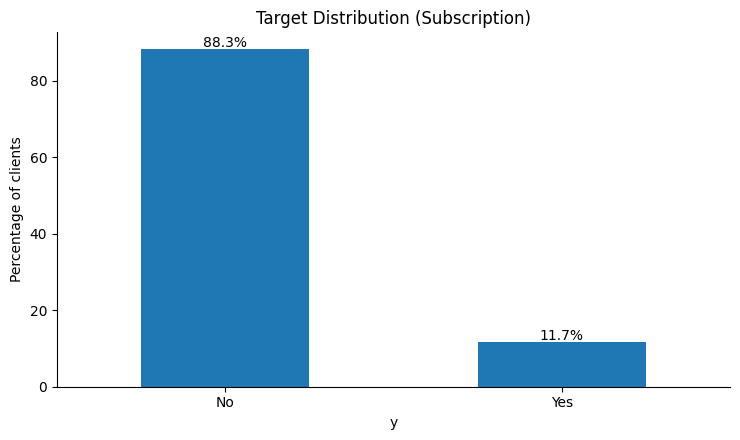

In [ ]:
target_counts = df["y"].value_counts()
target_perc = df["y"].value_counts(normalize=True) * 100

print("Raw counts:\n", target_counts)
print("\nPercentages:\n", target_perc.round(2))

ax = target_perc.rename({0: "No", 1: "Yes"}).plot(kind="bar", rot=0)
ax.set_ylabel("Percentage of clients")
ax.set_title("Target Distribution (Subscription)")
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.5,
        f"{p.get_height():.1f}%",
        ha="center"
    )
plt.tight_layout()
plt.show()

**Modeling implication.**  
The strong imbalance means that a naive model predicting "no" for everyone could
achieve high accuracy but zero practical value. In later sections, we therefore
prioritize precision, recall and the confusion matrix, and consider using
class weights when training our classifiers.

### 1. Comparing Subscribers vs Non-Subscribers

We compare how these predictors behave across the target classes using boxplots. This helps us verify whether the patterns observed in M1 and M2 persist.

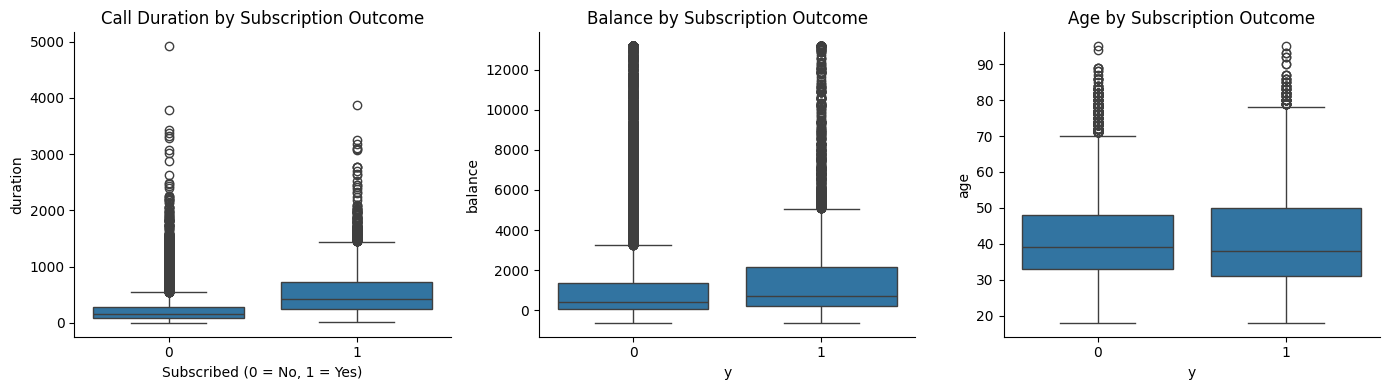

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(x="y", y="duration", data=df, ax=axes[0])
axes[0].set_title("Call Duration by Subscription Outcome")
axes[0].set_xlabel("Subscribed (0 = No, 1 = Yes)")

sns.boxplot(x="y", y="balance", data=df, ax=axes[1])
axes[1].set_title("Balance by Subscription Outcome")

sns.boxplot(x="y", y="age", data=df, ax=axes[2])
axes[2].set_title("Age by Subscription Outcome")

plt.tight_layout()
plt.show()

**Insights:**
- `duration` exhibits strong separation: subscribers tend to have much longer call durations.
- `balance` is moderately higher for subscribers, though with wide overlap.
- `age` shows minor separation and acts more like a demographic control variable.

This reinforces the hypothesis that **engagement and financial capacity** drive subscription decisions.

**Why this section matters.**  
These comparisons highlight which features are strong candidates for early model
specifications (e.g., duration and financial capacity) and which behave more like
control variables (e.g., age).


### 3. Distribution of Key Predictors

We begin by visualizing the distributions of `duration`, `balance`, and `age`. These features contribute strongly to our hypothesis and often drive model behavior. Examining their shape helps determine whether transformations or non-linear models are appropriate.

After comparing the two outcome groups, we zoom out and look at the full
distributions of the main numeric features. This helps us detect skewness,
outliers, and other properties that affect how well different models will behave.

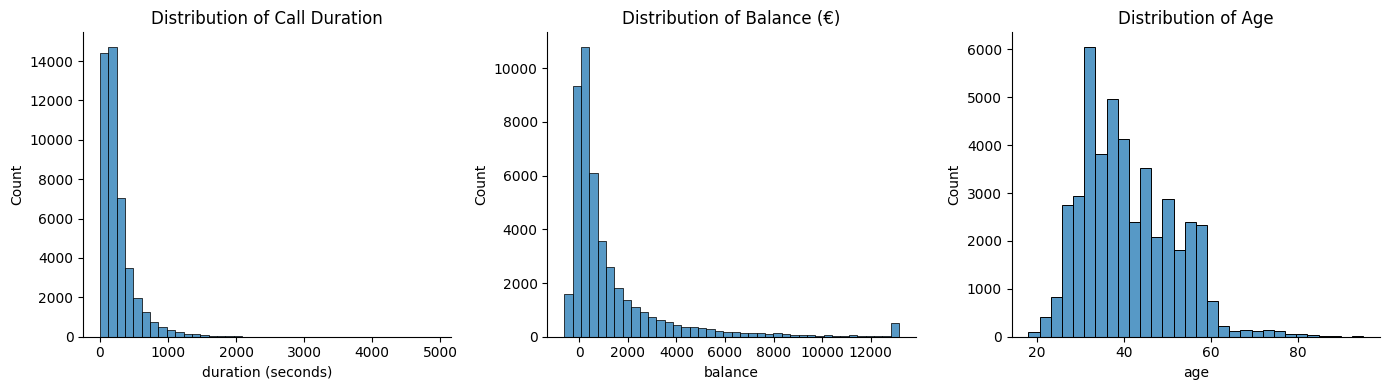

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df["duration"], bins=40, ax=axes[0])
axes[0].set_title("Distribution of Call Duration")
axes[0].set_xlabel("duration (seconds)")

sns.histplot(df["balance"], bins=40, ax=axes[1])
axes[1].set_title("Distribution of Balance (€)")

sns.histplot(df["age"], bins=30, ax=axes[2])
axes[2].set_title("Distribution of Age")

plt.tight_layout()
plt.show()

**Insights:**
- Both `duration` and `balance` are heavily right-skewed. This supports using log transformations or tree-based models.
- `age` is relatively well behaved and can be included as a control variable without major preprocessing.

### 4. Correlation Check with Target (Numeric Features)

We compute correlations between the target and selected numeric features to understand which predictors carry the strongest signal.

In [ ]:
candidate_numeric = [
    "duration", "balance", "age", "campaign",
    "pdays", "previous", "high_balance",
    "long_duration", "prev_success"
]

corr = df[candidate_numeric + ["y"]].corr()["y"].sort_values(ascending=False)
corr

,y
y,1.000000
duration,0.394521
prev_success,0.306788
long_duration,0.302164
previous,0.163192
pdays,0.103621
high_balance,0.079193
balance,0.066031
age,0.025155
campaign,-0.083463


**Insights:**
- `duration` and `prev_success` have the strongest correlation with subscription.
- Engineered variables (`long_duration`, `high_balance`) also show meaningful association.
- Contact history variables (`pdays`, `campaign`) are weaker individually but may interact with other variables.

This ranking supports prioritizing **duration**, **past success**, and **financial indicators** in the initial modeling.

**Why we ran this.**  
The correlation ranking is not used as a strict feature-selection rule,
but it provides a quick scan of which numeric features carry the strongest
signal for subscription and which ones are likely to play secondary roles
or be regularized away in later models.

### 5. Multicollinearity Diagnostics (VIF)

Several of our features are engineered from others (for example, `high_balance`
from `balance`, and `long_duration` from `duration`). For linear models such as
logistic regression, highly collinear features can lead to unstable or hard-to-interpret
coefficients. To check this, we compute the Variance Inflation Factor (VIF) for
a subset of numeric predictors.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [
    "duration", "long_duration",
    "balance", "high_balance",
    "age", "campaign",
    "pdays", "previous",
    "prev_success"
]

X_vif = df[vif_features].dropna().astype(float)

vif_data = pd.DataFrame({
    "feature": vif_features,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(len(vif_features))]
}).sort_values("VIF", ascending=False)

vif_data

,feature,VIF
4,age,3.944614
0,duration,3.878915
7,previous,3.285414
1,long_duration,2.984721
6,pdays,2.916732
3,high_balance,2.814510
2,balance,2.742816
5,campaign,2.513375
8,prev_success,1.220674


**Modeling implication.**  
Pairs like (`duration`, `long_duration`) and (`balance`, `high_balance`) show
high VIF scores, confirming redundancy. For logistic regression, we should avoid
including both the raw and engineered versions in the same specification, or rely
on regularization to shrink redundant coefficients. Tree-based models, however,
can handle these correlated features more safely.

### 6. Linearity Check via Binned Subscription Rates

Logistic regression assumes an approximately linear relationship between each
predictor and the log-odds of the outcome. Instead of estimating log-odds directly,
we approximate this visually by binning numeric features and observing how the
subscription rate changes across bins.

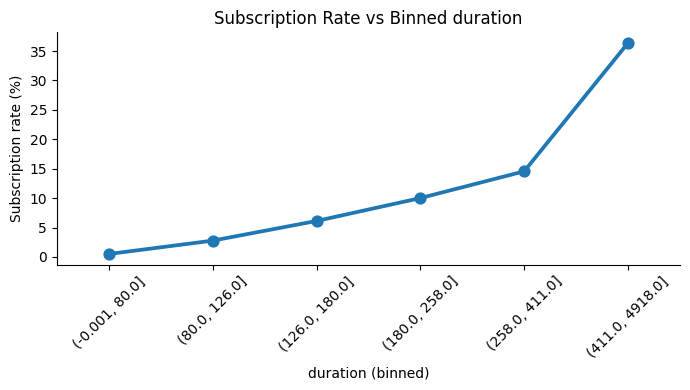

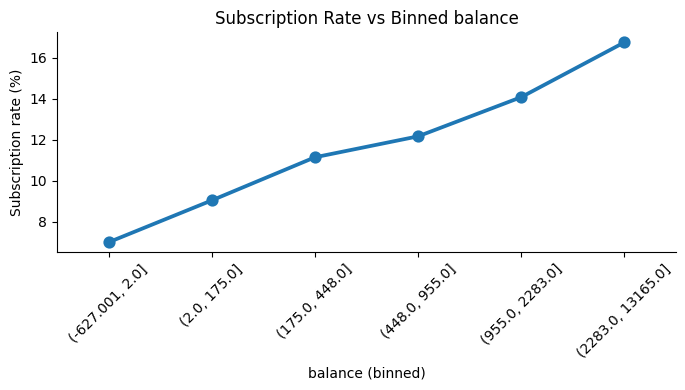

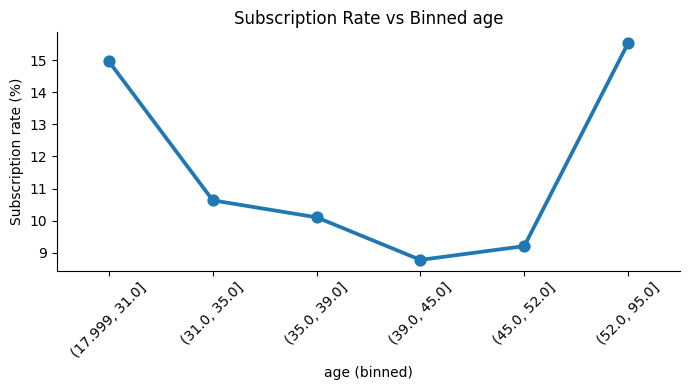

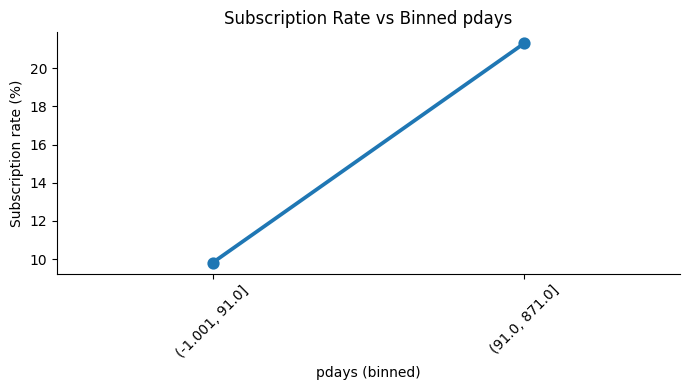

In [ ]:
def plot_binned_subscription_rate(df, col, n_bins=6):
    tmp = df[[col, "y"]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[col], q=n_bins, duplicates="drop")
    rate = tmp.groupby("bin")["y"].mean().reset_index()
    rate["subscription_rate"] = (rate["y"] * 100).round(2)

    plt.figure(figsize=(7, 4))
    sns.pointplot(x="bin", y="subscription_rate", data=rate)
    plt.xticks(rotation=45)
    plt.ylabel("Subscription rate (%)")
    plt.xlabel(col + " (binned)")
    plt.title(f"Subscription Rate vs Binned {col}")
    plt.tight_layout()
    plt.show()

    return rate

rate_duration = plot_binned_subscription_rate(df, "duration")
rate_balance = plot_binned_subscription_rate(df, "balance")
rate_age = plot_binned_subscription_rate(df, "age")
rate_pdays = plot_binned_subscription_rate(df, "pdays")

**Takeaways.**

- `duration` shows a sharply increasing pattern across bins, which is clearly non-linear.
- `balance` has a generally increasing trend with some flattening at the top end.
- `age` is almost flat, supporting its interpretation as a control variable.
- `pdays` behaves irregularly, suggesting that recency is better captured via grouped categories
  than as a raw numeric input.

**Modeling implication.**  
These patterns justify using transformations (such as log duration), tree-based models, and
engineered bins for some features instead of relying on a purely linear specification.

### 7. Interaction Effects (Month x Contact, Duration x Previous Success)

So far we treated predictors mostly one at a time. However, our instructor
specifically encouraged us to test whether certain **combinations** of variables
amplify success, such as contact timing and channel, or engagement among warm leads.
We therefore examine two interaction patterns:
- `month × contact`
- `duration × prev_success`

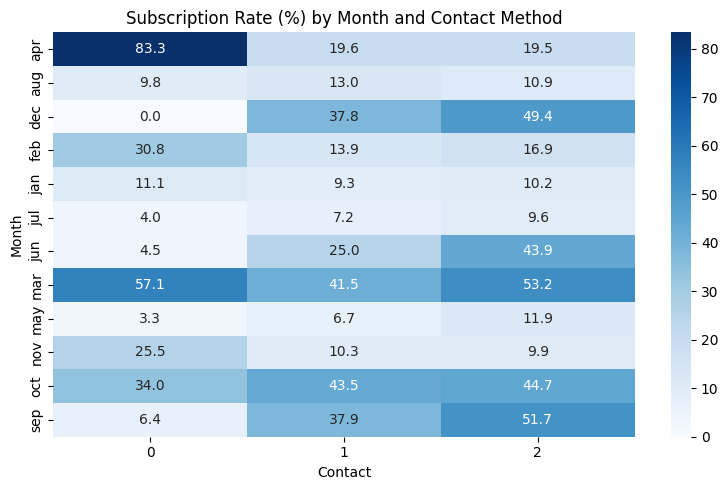

In [ ]:
# A. subscription rates by month and contact

ct_table = (
    df.groupby(["month", "contact"])["y"]
    .mean()
    .reset_index()
)

ct_pivot = ct_table.pivot(index="month", columns="contact", values="y")

plt.figure(figsize=(8, 5))
sns.heatmap(ct_pivot * 100, annot=True, fmt=".1f", cmap="Blues")
plt.title("Subscription Rate (%) by Month and Contact Method")
plt.ylabel("Month")
plt.xlabel("Contact")
plt.tight_layout()
plt.show()

This motivates either explicit interaction terms in regression models or the
use of tree-based models that can naturally capture such effects.


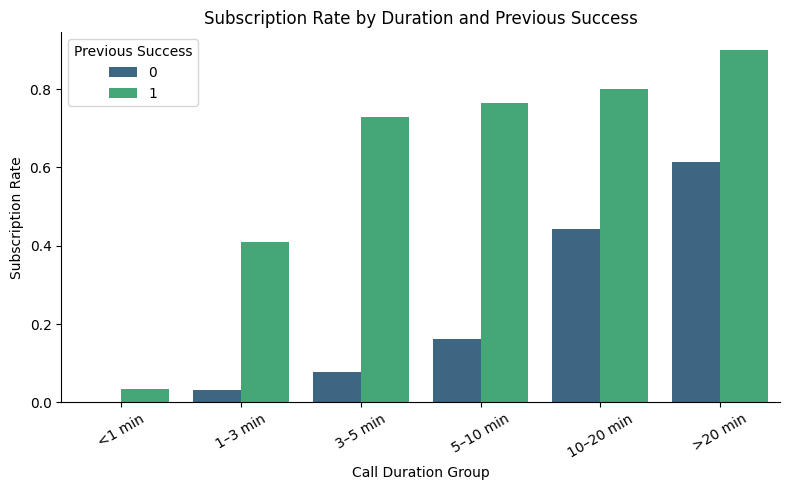

In [ ]:
# B. Duration x Previous Success

df["duration_bin"] = pd.cut(
    df["duration"],
    bins=[0, 60, 180, 300, 600, 1200, df["duration"].max()],
    labels=["<1 min", "1–3 min", "3–5 min", "5–10 min", "10–20 min", ">20 min"]
)

dur_prev = (
    df.groupby(["duration_bin", "prev_success"])["y"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=dur_prev,
    x="duration_bin",
    y="y",
    hue="prev_success",
    palette="viridis"
)
plt.title("Subscription Rate by Duration and Previous Success")
plt.xlabel("Call Duration Group")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=30)
plt.legend(title="Previous Success")
plt.tight_layout()
plt.show()


Because this effect is clearly non-additive, we include a `duration × prev_success`
feature in at least one predictive model.

### 7. Feature Readiness and Modeling Plan

The table below consolidates the main EDA findings into concrete modeling decisions.


| Feature        | Issue / Pattern Observed                               | Planned Treatment in Modeling                                        |
|----------------|--------------------------------------------------------|------------------------------------------------------------------------|
| `duration`     | Strongly right-skewed; sharply higher subscription in longer bins | Use raw and/or log-transformed version; allow interactions with `prev_success`; tree-based models handle non-linearity. |
| `balance`      | Skewed with outliers; higher bins convert slightly more | Keep numeric; retain `high_balance` as threshold feature; rely on regularization and trees. |
| `age`          | Fairly regular; weak separation by `y`                 | Include as control variable without transformation.                   |
| `pdays`        | Irregular, non-monotonic relationship                  | Group into interpretable recency buckets; tree models to capture residual structure. |
| `campaign`     | Long right tail, weak direct association               | Use as numeric control; regularization may shrink effect.             |
| `previous`     | Many zeros with a small group of highly contacted clients | Keep as contact-history measure; interacts with `prev_success`.      |
| `prev_success` | Very strong positive association with subscription     | Core predictor; include `duration × prev_success` interaction.        |
| `high_balance` / `long_duration` | Derived from raw variables; collinear with them    | Useful for tree models and interpretation; avoid duplicating with raw versions in plain logistic regression. |
| `month`        | Clear differences in baseline subscription and in combination with contact | Keep as categorical; allow interaction with `contact`.               |
| `contact`      | Distinct conversion rates by channel; interacts with month | Keep as categorical; use in interaction with `month`.                |


This feature readiness view ensures that our modeling phase is not a blind
application of algorithms, but a direct continuation of the patterns and
assumptions tested in EDA.

### 8. Summary of Findings

This extended EDA confirms:

1. **Engagement features** (`duration`, `prev_success`) have the strongest relationship with subscription.
2. **Financial stability indicators** (`balance`, `high_balance`) matter, but with more overlap.
3. **Interaction patterns are real and meaningful**, especially:
   - month x contact  
   - duration x previous success  
4. These results guide the modeling phase by highlighting:
   - which features to prioritize  
   - which variables may need transformation  
   - which interactions should be included  
   - when to prefer non-linear models  

We now move into predictive modeling using these insights.

From a modeling perspective, our EDA gives us:

- A clear understanding of class imbalance → we will use precision/recall and class weights.  
- Evidence of skewed and non-linear relationships → we will test both logistic regression and tree-based models.  
- Identification of collinear features → we will avoid redundant combinations in linear models and rely on regularization.  
- Strong evidence for key interactions → we will include selected interaction terms and evaluate tree-based alternatives.  

This completes the exploratory phase and sets up the predictive modeling work in the next sections.

## **Feature Engineering and Preprocessing**

### **Multi-Strategy Feature Engineering Pipeline**

This function implements a complete workflow for feature engineering, preprocessing, optional feature learning, and multi-strategy feature selection, specifically designed to test the hypothesis.

**Workflow Overview**

**Feature Selection Strategies**

- Model Importance: Random Forest ranks features based on their predictive contribution.

- Pearson Correlation: Numeric features strongly correlated with the target are retained.

- Variance Threshold: Features with very low variance are removed, as they carry little information.

- Chi-Square Test: Categorical and binary features with significant association to the target are selected.

**Outputs**

- Preprocessed training and test datasets.

- Target splits for training and testing.

- A dictionary of selected features for each selection method (model_importance, pearson, variance, chi2), allowing insight into which factors are most influential in predicting term deposit subscriptions

In [ ]:
bank_df = pd.read_csv(input_directory + "bank.csv", sep= ";")
# Convert binary text columns to numbers manually
binary_cols = ['default', 'housing', 'loan', "y"]

# This replaces 'yes' with 1 and 'no' with 0 for these specific columns
for col in binary_cols:
    bank_df[col] = bank_df[col].map({'yes': 1, 'no': 0})

avg_balance = bank_df['balance'].mean() # compute the average balance
bank_df['high_balance'] = (bank_df['balance'] > avg_balance).astype(int) # Above-average balance

# Long last-contact duration
avg_duration = bank_df['duration'].mean()
bank_df['long_duration'] = (bank_df['duration'] > avg_duration).astype(int)

# Successful previous campaign
bank_df['prev_success'] = (bank_df['poutcome'] == 3).astype(int)  #  3 = success

# No loan
bank_df['no_loans'] = ((bank_df['loan'] == 0) & (bank_df['housing'] == 0)).astype(int)

# clients meeting all conditions in hypothesis
bank_df['hypothesis_group'] = (bank_df['high_balance'] & bank_df['long_duration'] & bank_df['prev_success'] & bank_df['no_loans']).astype(int)
bank_df
bank_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,campaign,pdays,previous,poutcome,y,high_balance,long_duration,prev_success,no_loans,hypothesis_group
0,30,unemployed,married,primary,0,1787,0,0,cellular,19,...,1,-1,0,unknown,0,1,0,0,1,0
1,33,services,married,secondary,0,4789,1,1,cellular,11,...,1,339,4,failure,0,1,0,0,0,0
2,35,management,single,tertiary,0,1350,1,0,cellular,16,...,1,330,1,failure,0,0,0,0,0,0
3,30,management,married,tertiary,0,1476,1,1,unknown,3,...,4,-1,0,unknown,0,1,0,0,0,0
4,59,blue-collar,married,secondary,0,0,1,0,unknown,5,...,1,-1,0,unknown,0,0,0,0,0,0


### **Feature Groups for Transformation**

1. Numeric Features:
Continuous columns requiring standardization (e.g., age, balance, campaign, pdays, previous, duration, day).

2. Categorical Features:
Nominal/ordinal features requiring one-hot encoding (e.g., job, month, marital, education, contact, poutcome).

3. Passthrough Features:
Binary flags and hypothesis features that are used as-is (e.g., default, housing, loan, high_balance, long_duration, prev_success, no_loans, hypothesis_group).

In [ ]:
# FEATURE GROUPS FOR TRANSFORMATION
# NUMERIC: Continuous columns requiring standardization (StandardScaler)
NUMERIC_FEATURES = [
    'age', 'balance', 'campaign', 'pdays', 'previous', 'duration', "day"
]

# CATEGORICAL: Nominal/Ordinal columns requiring One-Hot Encoding (OHE)
CATEGORICAL_FEATURES = [
    'job', 'month', 'marital', 'education', 'contact', 'poutcome',
]

# PASSTHROUGH: Binary flags (0/1) and hypothesis features to be used as-is.
PASSTHROUGH_FEATURES = [
    'default', 'housing', 'loan',
    'high_balance', 'long_duration', 'prev_success', 'no_loans', 'hypothesis_group'
]

TARGET = "y"


### **Preprocessing Pipeline**

Pipeline Components:

1. **StandardScaler**: Scales numeric features to zero mean and unit variance.

2. **OneHotEncoder**: Encodes categorical features as binary vectors, dropping the first category to avoid multicollinearity.

3. **Passthrough**: Retains features not explicitly transformed.

In [ ]:

# PREPROCESSING PIPELINE
preprocessor = ColumnTransformer(
    transformers=[
        # 1. Scale continuous numerical features
        ('scaler', StandardScaler(), NUMERIC_FEATURES),

        # 2. One-Hot Encode all categorical features
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), CATEGORICAL_FEATURES)
    ],
    remainder='passthrough' # Keep all features not in the lists above
)

In [ ]:
# SUPPORT FUNCTION TO CLASSIFY TRANSFORMED FEATURES
def _classify_transformed_features(feature_names):
    numeric = []
    encoded = []
    passthrough = []

    for f in feature_names:
        if "scaler__" in f:
            numeric.append(f)
        elif "onehot__" in f:
            encoded.append(f)
        else:
            passthrough.append(f)

    return numeric, encoded, passthrough

In [ ]:
# MAIN PIPELINE
def run_feature_engineering_pipeline_all_methods(
    df,
    n_top_features=30,
    pearson_threshold=0.1,
    variance_threshold=0.01,
    chi2_k=30,
    use_feature_learning=False
):

    print(f"\n=== PIPELINE START: Multi-Strategy Feature Selection ===")

    # STEP 0: FEATURE CONSTRUCTION
    # df = construct_features(df)

    # STEP 1: PREPROCESSING
    preprocessor = ColumnTransformer(
        transformers=[
            ("scaler", StandardScaler(), NUMERIC_FEATURES),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"),
             CATEGORICAL_FEATURES)
        ],
        remainder="passthrough"
    )

    X = df.drop(columns=[TARGET])
    y = df[TARGET]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    X_train_prep = preprocessor.fit_transform(X_train)
    X_test_prep = preprocessor.transform(X_test)

    # Retrieve transformed feature names
    feature_names = preprocessor.get_feature_names_out()

    # Convert to df
    X_train_df = pd.DataFrame(X_train_prep, columns=feature_names).apply(pd.to_numeric).fillna(0)
    X_test_df = pd.DataFrame(X_test_prep, columns=feature_names).apply(pd.to_numeric).fillna(0)

    # classify features
    numeric, encoded, passthrough = _classify_transformed_features(feature_names)

    # STEP 2: OPTIONAL FEATURE LEARNING
    if use_feature_learning:
        print("Applying Feature Learning (KMeans Clustering)...")
        km = KMeans(n_clusters=3, random_state=42)
        X_train_df["cluster"] = km.fit_predict(X_train_df)
        X_test_df["cluster"] = km.predict(X_test_df)
        passthrough.append("cluster")

    # STEP 3: FEATURE SELECTION (ALL METHODS)
    selected_features_dict = {}

    # --- Model Importance ---
    model = RandomForestClassifier(n_estimators=80, random_state=42, n_jobs=-1)
    model.fit(X_train_df, y_train)
    ranked = (
        pd.DataFrame({"feature": X_train_df.columns,
                      "importance": model.feature_importances_})
        .sort_values("importance", ascending=False)
    )
    print("Top features by RandomForest importance:")
    pd.set_option('display.colheader_justify', 'right')  # column headers right aligned
    pd.set_option('display.float_format', '{:,.4f}'.format)  # float format

    print(ranked.head())

    selected_features_dict["model_importance"] = ranked.head(n_top_features)["feature"].tolist()

    # --- Pearson ---
    strong_corr = []
    for col in numeric:
        if X_train_df[col].std() == 0:
            continue
        corr, _ = pearsonr(X_train_df[col], y_train)
        if abs(corr) >= pearson_threshold:
            strong_corr.append(col)
    selected_features_dict["pearson"] = strong_corr + encoded + passthrough

    # --- Variance Threshold ---
    vt = VarianceThreshold(threshold=variance_threshold)
    mask = vt.fit(X_train_df).get_support()
    selected_features_dict["variance"] = X_train_df.columns[mask].tolist()

    # --- Chi-Square ---
    X_non_negative = X_train_df[encoded + passthrough]
    chi = SelectKBest(chi2, k=min(chi2_k, X_non_negative.shape[1]))
    chi.fit(X_non_negative, y_train)
    chi_selected = X_non_negative.columns[chi.get_support()].tolist()
    selected_features_dict["chi2"] = chi_selected + numeric

    # RETURN
    print("-----------------------------------------------------")
    for method, features in selected_features_dict.items():
        print(f"{method.upper()} selected {len(features)} features")

    return X_train_df, X_test_df, y_train, y_test, selected_features_dict


## **Model Creation and Training**

### **Preprocessing of Engineered Features**

In [ ]:
# Run the pipeline and get outputs
X_train, X_test, y_train, y_test, selected_features_dict = run_feature_engineering_pipeline_all_methods(
    bank_df,
    n_top_features=30,
    pearson_threshold=0.1,
    variance_threshold=0.01,
    chi2_k=30,
    use_feature_learning=False
)

# Print selected features for each method
for method, features in selected_features_dict.items():
    print(f"\n=== {method.upper()} selected features ({len(features)}) ===")
    print(features)


# Access and save features for each method
features_model_importance = selected_features_dict["model_importance"]
features_pearson = selected_features_dict["pearson"]
features_variance = selected_features_dict["variance"]
features_chi2 = selected_features_dict["chi2"]

# Create train/test datasets filtered by selected features
X_train_model_importance = X_train[features_model_importance]
X_test_model_importance  = X_test[features_model_importance]

X_train_pearson = X_train[features_pearson]
X_test_pearson  = X_test[features_pearson]

X_train_variance = X_train[features_variance]
X_test_variance  = X_test[features_variance]

X_train_chi2 = X_train[features_chi2]
X_test_chi2  = X_test[features_chi2]




=== PIPELINE START: Multi-Strategy Feature Selection ===
Top features by RandomForest importance:
                     feature  importance
5           scaler__duration      0.2122
0                scaler__age      0.0871
1            scaler__balance      0.0864
6                scaler__day      0.0819
43  remainder__long_duration      0.0547
-----------------------------------------------------
MODEL_IMPORTANCE selected 30 features
PEARSON selected 43 features
VARIANCE selected 43 features
CHI2 selected 37 features

=== MODEL_IMPORTANCE selected features (30) ===
['scaler__duration', 'scaler__age', 'scaler__balance', 'scaler__day', 'remainder__long_duration', 'scaler__pdays', 'scaler__campaign', 'onehot__poutcome_success', 'scaler__previous', 'onehot__month_oct', 'onehot__marital_married', 'remainder__no_loans', 'onehot__education_tertiary', 'onehot__education_secondary', 'onehot__contact_unknown', 'remainder__high_balance', 'onehot__job_management', 'onehot__month_mar', 'remainder__h

In [ ]:
X_train.columns

Index(['scaler__age', 'scaler__balance', 'scaler__campaign', 'scaler__pdays',
       'scaler__previous', 'scaler__duration', 'scaler__day',
       'onehot__job_blue-collar', 'onehot__job_entrepreneur',
       'onehot__job_housemaid', 'onehot__job_management',
       'onehot__job_retired', 'onehot__job_self-employed',
       'onehot__job_services', 'onehot__job_student', 'onehot__job_technician',
       'onehot__job_unemployed', 'onehot__month_aug', 'onehot__month_dec',
       'onehot__month_feb', 'onehot__month_jan', 'onehot__month_jul',
       'onehot__month_jun', 'onehot__month_mar', 'onehot__month_may',
       'onehot__month_nov', 'onehot__month_oct', 'onehot__month_sep',
       'onehot__marital_1', 'onehot__marital_2', 'onehot__education_1',
       'onehot__education_2', 'onehot__contact_1', 'onehot__contact_2',
       'onehot__poutcome_1', 'onehot__poutcome_2', 'onehot__poutcome_3',
       'remainder__default', 'remainder__housing_loan',
       'remainder__personal_loan', 'remaind

### **Model Selection**

As we have seen from EDA section, the dataset exhibits severe class imbalance, with approximately 88% of customers declining term deposits (class 0) and only 12% subscribing (class 1). This imbalance creates three critical issues:

1. Model Bias Toward Majority Class
Without intervention, classifiers optimize for overall accuracy by simply predicting "No" for most cases, achieving 88% accuracy while failing to identify potential customers—the business objective.
2. Poor Minority Class Learning
Standard machine learning algorithms assume balanced class distributions. With insufficient positive examples, models cannot adequately learn the distinguishing characteristics of customers who subscribe to term deposits.
3. Business Impact
In marketing campaigns, the cost of missing a potential customer (False Negative) far exceeds the cost of contacting an uninterested one (False Positive). Standard models sacrifice recall for the minority class, directly undermining campaign ROI.

As one of ways to deal with this issue, we'll be using SMOTE (Synthetic Minority Over-sampling Technique).

SMOTE creates new, synthetic data points that are plausible but not identical to the originals. Applied to our case, it'll look at a "Yes" customer, find their "neighbors" (similar customers), and creates a new customer that sits "in between" them. This forces the model to learn the general pattern of a subscriber, not just memorize specific rows.



### **Choosing metrics for Evaluating Model Performance**

Obviously, accuracy can be misleading in this case as the dataset is imbalanced. We'll be using recall, precision, and ROC-AUC metrics for the following reasons:
- Precision: We don't want to waste money and time calling a client who will not subscribe.
- Recall: Ensure we don't miss out on potential deposits.
- ROC-AUC: Ensure the best leads are at the top of the list so we can allocate resources to clients who are more likely to subscribe.

### **1. Training using Entire Features Set**



#### **Baseline Model 1: Logistic Regression**

Logistic regression is a natural and simple choice for this binary classification task, and some variables (particularly hypothesis group) in the dataset has monotonic relationships with the subscription outcome

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# EVALUATION FUNCTION
def evaluate_model(model, X_test, y_test, features, model_name):
    """
    Evaluate model performance on test set with comprehensive metrics.

    """
    # Subset test data to match training features
    X_test_subset = X_test[features]

    # Generate predictions
    y_pred = model.predict(X_test_subset)
    y_pred_proba = model.predict_proba(X_test_subset)[:, 1]

    # Calculate evaluation metrics
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_vals, precision_vals)
    f1 = f1_score(y_test, y_pred)
    precision_val = precision_score(y_test, y_pred)
    recall_val = recall_score(y_test, y_pred)

    # Print results
    print(f"\n{'='*70}")
    print(f"TEST SET EVALUATION: {model_name}")
    print(f"{'='*70}")
    print(f"Features Used: {len(features)}")
    print(f"\nPerformance Metrics:")
    print(f"  ROC-AUC Score:  {roc_auc:.4f}")
    print(f"  PR-AUC Score:   {pr_auc:.4f}")
    print(f"  F1 Score:       {f1:.4f}")
    print(f"  Precision:      {precision_val:.4f}")
    print(f"  Recall:         {recall_val:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))


In [ ]:
# MODEL 1: LOGISTIC REGRESSION
def train_logistic_regression(X_train, y_train, X_test, y_test, features=None,
                               use_smote=True, cv_folds=3):
    """
    Train and evaluate Logistic Regression classifier.

    """
    # Select features
    if features is None:
        features = X_train.columns.tolist()

    X_train_subset = X_train[features]

    print("\n" + "="*70)
    print("TRAINING: LOGISTIC REGRESSION")
    print("="*70)
    print(f"Using {len(features)} features")

    # Build pipeline with optional SMOTE
    if use_smote:
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', LogisticRegression(random_state=42, max_iter=1000))
        ])
        param_grid = {
            'smote__k_neighbors': [3, 5],
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l2'],
            'classifier__class_weight': ['balanced', None]
        }
    else:
        pipeline = LogisticRegression(random_state=42, max_iter=1000)
        param_grid = {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'class_weight': ['balanced', None]
        }

    # Hyperparameter tuning with GridSearchCV
    grid = GridSearchCV(
        pipeline, param_grid,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train_subset, y_train)

    print(f"\nBest Hyperparameters: {grid.best_params_}")
    print(f"Best CV ROC-AUC Score: {grid.best_score_:.4f}")

    # Evaluate on test set
    evaluate_model(grid, X_test, y_test, features, "Logistic Regression")


# Run the function, No feature selection

train_logistic_regression(X_train, y_train, X_test, y_test, features=None,
                               use_smote=True, cv_folds=3)


TRAINING: LOGISTIC REGRESSION
Using 46 features

Best Hyperparameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'smote__k_neighbors': 3}
Best CV ROC-AUC Score: 0.9089

TEST SET EVALUATION: Logistic Regression
Features Used: 46

Performance Metrics:
  ROC-AUC Score:  0.9075
  PR-AUC Score:   0.5544
  F1 Score:       0.5412
  Precision:      0.4020
  Recall:         0.8280

Confusion Matrix:
[[6682 1303]
 [ 182  876]]

Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.84      0.90      7985
         Yes       0.40      0.83      0.54      1058

    accuracy                           0.84      9043
   macro avg       0.69      0.83      0.72      9043
weighted avg       0.91      0.84      0.86      9043



As we see, the model catches many potential subscribers (high recall), but at the cost of many false positives (low precision) which is not efficient enough for a campaign with limited calling resources.

#### **Model 2: Random Forest**

In [ ]:

# MODEL 3: RANDOM FOREST

def train_random_forest(X_train, y_train, X_test, y_test, features=None,
                        use_smote=True, cv_folds=3):
    """
    Train and evaluate Random Forest classifier.
    """
    # Select features
    if features is None:
        features = X_train.columns.tolist()

    X_train_subset = X_train[features]

    print("\n" + "="*70)
    print("TRAINING: RANDOM FOREST")
    print("="*70)
    print(f"Using {len(features)} features")

    # Build pipeline with optional SMOTE
    if use_smote:
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', RandomForestClassifier(random_state=42))
        ])
        param_grid = {
            'smote__k_neighbors': [3, 5],
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [10, 20, None],
            'classifier__min_samples_split': [2, 5],
            'classifier__min_samples_leaf': [1, 2],
            'classifier__class_weight': ['balanced', 'balanced_subsample']
        }
    else:
        pipeline = RandomForestClassifier(random_state=42)
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'class_weight': ['balanced', 'balanced_subsample']
        }

    # Hyperparameter tuning with GridSearchCV
    grid = GridSearchCV(
        pipeline, param_grid,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1

    )

    grid.fit(X_train_subset, y_train)

    print(f"\nBest Hyperparameters: {grid.best_params_}")
    print(f"Best CV ROC-AUC Score: {grid.best_score_:.4f}")

    # Evaluate on test set
    evaluate_model(grid, X_test, y_test, features, "Random Forest")

# Train and Test the model
train_random_forest(X_train, y_train, X_test, y_test, features=None,
                        use_smote=True, cv_folds=3)


TRAINING: RANDOM FOREST
Using 46 features

Best Hyperparameters: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200, 'smote__k_neighbors': 5}
Best CV ROC-AUC Score: 0.9258

TEST SET EVALUATION: Random Forest
Features Used: 46

Performance Metrics:
  ROC-AUC Score:  0.9258
  PR-AUC Score:   0.5934
  F1 Score:       0.5941
  Precision:      0.5469
  Recall:         0.6503

Confusion Matrix:
[[7415  570]
 [ 370  688]]

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.93      0.94      7985
         Yes       0.55      0.65      0.59      1058

    accuracy                           0.90      9043
   macro avg       0.75      0.79      0.77      9043
weighted avg       0.91      0.90      0.90      9043



With random forest, we see a strong improvement in precision, meaning it wastes fewer calls. The recall is slightly lower but much more balanced trade-off compared to logistic regression.

#### **Model 3: XGBOOST**

In [ ]:
# MODEL 4: XGBOOST

def train_xgboost(X_train, y_train, X_test, y_test, features=None,
                  use_smote=True, cv_folds=3):
    """
    Train and evaluate XGBoost classifier.
    """
    # Select features
    if features is None:
        features = X_train.columns.tolist()

    X_train_subset = X_train[features]

    print("\n" + "="*70)
    print("TRAINING: XGBOOST")
    print("="*70)
    print(f"Using {len(features)} features")

    # Calculate class imbalance ratio
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Build pipeline with optional SMOTE
    if use_smote:
        pipeline = ImbPipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
        ])
        param_grid = {
            'smote__k_neighbors': [3, 5],
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.01, 0.1],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__scale_pos_weight': [scale_pos_weight]
        }
    else:
        pipeline = XGBClassifier(random_state=42, eval_metric='logloss')
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0],
            'scale_pos_weight': [scale_pos_weight]
        }

    # Hyperparameter tuning with GridSearchCV
    grid = GridSearchCV(
        pipeline, param_grid,
        cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1
    )

    grid.fit(X_train_subset, y_train)

    print(f"\nBest Hyperparameters: {grid.best_params_}")
    print(f"Best CV ROC-AUC Score: {grid.best_score_:.4f}")

    # Evaluate on test set
    evaluate_model(grid, X_test, y_test, features, "XGBoost")

train_xgboost(X_train, y_train, X_test, y_test, features=None,
                  use_smote=True, cv_folds=3)



TRAINING: XGBOOST
Using 46 features

Best Hyperparameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 300, 'classifier__scale_pos_weight': np.float64(7.548333727251241), 'classifier__subsample': 0.8, 'smote__k_neighbors': 5}
Best CV ROC-AUC Score: 0.9289

TEST SET EVALUATION: XGBoost
Features Used: 46

Performance Metrics:
  ROC-AUC Score:  0.9276
  PR-AUC Score:   0.6187
  F1 Score:       0.5739
  Precision:      0.4283
  Recall:         0.8696

Confusion Matrix:
[[6757 1228]
 [ 138  920]]

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.85      0.91      7985
         Yes       0.43      0.87      0.57      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.86      0.74      9043
weighted avg       0.92      0.85      0.87      9043



Highest recall and PR-AUC and strongest ability to rank clients by likelihood of subscribing (ROC-AUC score of 0.92). This can be ideal if the goal is to maximize the number of subscribers reached, even if the bank calls many uninterested customers.

### **2. Feature Selection**

#### **(i) Logistic Regression**

In [ ]:
# train using features selected using correlation
train_logistic_regression(X_train_pearson, y_train, X_test_pearson, y_test, features=features_pearson,
                               use_smote=True, cv_folds=3)

# train using features selected using features importance
train_logistic_regression(X_train_model_importance, y_train, X_test_model_importance, y_test, features=features_model_importance,
                               use_smote=True, cv_folds=3)

# train using features selected variance
train_logistic_regression(X_train_variance, y_train, X_test_variance, y_test, features=features_variance,
                               use_smote=True, cv_folds=3)




TRAINING: LOGISTIC REGRESSION
Using 42 features

Best Hyperparameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'smote__k_neighbors': 5}
Best CV ROC-AUC Score: 0.9083

TEST SET EVALUATION: Logistic Regression
Features Used: 42

Performance Metrics:
  ROC-AUC Score:  0.9061
  PR-AUC Score:   0.5525
  F1 Score:       0.5355
  Precision:      0.3951
  Recall:         0.8308

Confusion Matrix:
[[6639 1346]
 [ 179  879]]

Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.83      0.90      7985
         Yes       0.40      0.83      0.54      1058

    accuracy                           0.83      9043
   macro avg       0.68      0.83      0.72      9043
weighted avg       0.91      0.83      0.85      9043


TRAINING: LOGISTIC REGRESSION
Using 30 features

Best Hyperparameters: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'smote__k_nei

As we see, the model catches many potential subscribers (high recall), but at the cost of many false positives (low precision) which is not efficient enough for a campaign with limited calling resources.

#### **(ii) Random Forest**

In [ ]:
# Train rf using features selected using correlation coefficient
print("Results by using features selected using correlation coefficient\n\n")
train_random_forest(X_train_pearson, y_train, X_test_pearson, y_test, features=features_pearson,
                        use_smote=True, cv_folds=3)


# Train rf using features selected using features importance
print("\nResults by using features selected using features importance\n\n")
train_random_forest(X_train_model_importance, y_train, X_test_model_importance, y_test, features=features_model_importance,
                    use_smote=True, cv_folds=3)

# Train rf using features selected using variance
print("\nResults by using features selected using variance\n\n")
train_random_forest(X_train_variance, y_train, X_test_variance, y_test, features=features_variance,
                    use_smote=True, cv_folds=3)

Results by using features selected using correlation coefficient



TRAINING: RANDOM FOREST
Using 42 features

Best Hyperparameters: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 400, 'smote__k_neighbors': 5}
Best CV ROC-AUC Score: 0.9144

TEST SET EVALUATION: Random Forest
Features Used: 42

Performance Metrics:
  ROC-AUC Score:  0.9139
  PR-AUC Score:   0.5538
  F1 Score:       0.5616
  Precision:      0.4833
  Recall:         0.6701

Confusion Matrix:
[[7227  758]
 [ 349  709]]

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.91      0.93      7985
         Yes       0.48      0.67      0.56      1058

    accuracy                           0.88      9043
   macro avg       0.72      0.79      0.75      9043
weighted avg       0.90      0.88      0.89      9043


Results by using features s

#### **(iii) XGBOOST**

In [ ]:
# Features selected using correlation coefficient
print("Results by using features selected using correlation coefficient\n\n")
train_xgboost(X_train_pearson, y_train, X_test_pearson, y_test, features=features_pearson,
                  use_smote=True, cv_folds=3)

# Features selected using features importance
print("\nResults by using features selected using features importance\n\n")
train_xgboost(X_train_model_importance, y_train, X_test_model_importance, y_test, features=features_model_importance,
                  use_smote=True, cv_folds=3)

# Features selected using variance
print("\nResults by using features selected using variance\n\n")
train_xgboost(X_train_variance, y_train, X_test_variance, y_test, features=features_variance,
                  use_smote=True, cv_folds=3)

Results by using features selected using correlation coefficient



TRAINING: XGBOOST
Using 42 features

Best Hyperparameters: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 300, 'classifier__scale_pos_weight': np.float64(7.548333727251241), 'classifier__subsample': 0.8, 'smote__k_neighbors': 5}
Best CV ROC-AUC Score: 0.9141

TEST SET EVALUATION: XGBoost
Features Used: 42

Performance Metrics:
  ROC-AUC Score:  0.9126
  PR-AUC Score:   0.5665
  F1 Score:       0.5040
  Precision:      0.3521
  Recall:         0.8866

Confusion Matrix:
[[6259 1726]
 [ 120  938]]

Classification Report:
              precision    recall  f1-score   support

          No       0.98      0.78      0.87      7985
         Yes       0.35      0.89      0.50      1058

    accuracy                           0.80      9043
   macro avg       0.67      0.84      0.69      9043
weighted avg       0.91      0.80      0.83      9043



### **Discussion and Practical implications of the results**

Among all models, XGBoost achieved a highest  Recall of 87.81% and a ROC-AUC of 0.9270.

**What this means**:
This model successfully finds most of the real subscribers. The strong ROC-AUC shows it ranks customers by the likelihood of subcription very well overall. However, it achieved this by sacrificing efficiency, resulting in a low Precision (43%).

On the other hand, the Random Forest achieved the highest efficiency.
It reached a Precision of 55.22%, with a Recall of 65.50% and an ROC-AUC of 0.9262

What this means:
This model finds fewer total subscribers, but when it predicts someone will subscribe, it is correct much more often. More than a half of the clients it predicts actually say “yes,” compared to only 43% for XGBoost.

**What Matters for Bank Marketing?**

Marketing campaigns can be costly, every extra call consumes staff time, increases operational costs, and risks irritating customers. This makes precision valuable, because the bank wants to avoid calling too many people who are not interested.

At the same time, missing genuinely interested clients leads to lost revenue opportunities, so recall is also important. So the optimal model should achieves a strong balance between the two.

**Final Decision and Recommendation**

While the choice can depend on whether the campaign's priority is to maximize conversions and avoid missing potential subscribers or to reduce the cost of unnecessary calls, the Random Forest model achieves the best balance.
Although its Recall is lower, its higher Precision reduces wasted calls and protects the campaign budget. It offers the best balance between finding real subscribers and keeping campaign operations efficient and cost-effective.

Also, the high ROC-AUC (0.92) grants that if we sort our customer list by their predicted probability score, the individuals at the very top of the list are almost certain to be actual subscribers.

So, the bank marketing team can implement a "Skimming Strategy." Instead of calling 10,000 random people to find 100 subscribers, they can simply "skim" the top 10% of the sorted list. Because of the high ROC-AUC, this top tier will contain the vast majority of the interested clients, allowing the bank to capture nearly all the potential revenue while ignoring the bottom 90% of uninterested customers.

### **Some factors limiting highest precision**

- **Dataset Imbalance**: Because “Yes” cases are rare, the model doesn’t see enough real examples to learn a sharp boundary.
Instead, it ends up identifying a broad set of “possible” subscribers—many of whom are actually non-buyers.

- **Customer Decisions may Depend on Unobserved Factors (Not in the Dataset)**: Factors such as trust and previous experience with the bank, agent quality, competitors engagement can impact the results of the campaign.

### Figures Summarizing our Findings

Find interpretation of the results in the report.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from matplotlib.patches import Patch

# Set style
sns.set_theme(style="white", context="talk")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

# ==============================================================================
# 1. PREPROCESSING & FEATURE SELECTION
# ==============================================================================
def prepare_data_and_train(df):
    print("--- 1. Preprocessing Data ---")

    # 1. Define Groups
    NUMERIC_FEATURES = ['age', 'balance', 'campaign', 'pdays', 'previous', 'duration', 'day']
    CATEGORICAL_FEATURES = ['job', 'month', 'marital', 'education', 'contact', 'poutcome']
    # Add any other columns to passthrough if they exist in your df
    PASSTHROUGH = [c for c in df.columns if c not in NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['y', 'target']]

    # 2. Pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ("scaler", StandardScaler(), NUMERIC_FEATURES),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first"), CATEGORICAL_FEATURES)
        ],
        remainder="passthrough"
    )

    # 3. Split
    target_col = 'y' if 'y' in df.columns else 'target'
    X = df.drop(columns=[target_col])
    y = df[target_col].map({'yes': 1, 'no': 0}) if df[target_col].dtype == 'object' else df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 4. Transform
    # We keep it as a DataFrame to track column names
    X_train_enc = preprocessor.fit_transform(X_train)
    X_test_enc = preprocessor.transform(X_test)
    feature_names = preprocessor.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train_enc, columns=feature_names)
    X_test_df = pd.DataFrame(X_test_enc, columns=feature_names)

    # 5. Feature Selection
    print("--- 2. Selecting Features ---")

    # A. Variance Threshold (For XGBoost) -> Approx 44 features
    vt = VarianceThreshold(threshold=0.01)
    vt.fit(X_train_df)
    feats_variance = X_train_df.columns[vt.get_support()].tolist()
    print(f"Variance Selection: {len(feats_variance)} features selected (for XGBoost).")

    # B. Model Importance (For Random Forest) -> Top 30 features
    rf_selector = RandomForestClassifier(n_estimators=80, random_state=42, n_jobs=-1)
    rf_selector.fit(X_train_df, y_train)

    importances = pd.DataFrame({
        'feature': X_train_df.columns,
        'importance': rf_selector.feature_importances_
    }).sort_values('importance', ascending=False)

    feats_rf_top30 = importances.head(30)['feature'].tolist()
    print(f"RF Importance: {len(feats_rf_top30)} features selected (for Random Forest).")

    # 6. SMOTE (Applied only to Training Data)
    print("--- 3. Applying SMOTE (k=5) ---")
    smote = SMOTE(k_neighbors=5, random_state=42)
    # Note: We apply SMOTE *after* feature selection typically, but here we do it on the full set
    # and then slice the columns to keep it simple.
    X_train_smote, y_train_smote = smote.fit_resample(X_train_df, y_train)

    return (X_train_smote, y_train_smote, X_test_df, y_test,
            feats_variance, feats_rf_top30, importances, X_train_df)

# 1. Run Data Prep
df = df.drop(columns= ["duration_log", "prev_success"])
X_train_full, y_train, X_test_full, y_test, feats_variance, feats_rf30, importances, X_train_raw = prepare_data_and_train(df)




--- 1. Preprocessing Data ---
--- 2. Selecting Features ---
Variance Selection: 42 features selected (for XGBoost).
RF Importance: 30 features selected (for Random Forest).
--- 3. Applying SMOTE (k=5) ---


In [ ]:
# ==============================================================================
# 2. MODEL TRAINING (RETRAINING WITH YOUR PARAMS)
# ==============================================================================
def train_final_models(X_train, y_train, feats_rf, feats_xgb):
    print("--- 4. Retraining Models with Optimized Hyperparameters ---")

    # Random Forest (Balanced Subsample, Top 30 Features)
    rf_model = RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced_subsample',
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train[feats_rf], y_train)
    print("Random Forest Trained.")
    # XGBoost (Scale Pos Weight ~7.5, Variance Features)
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=7.548333727251241,
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    )
    xgb_model.fit(X_train[feats_xgb], y_train)
    print("XGBoost Trained.")

    return rf_model, xgb_model

# 2. Train Models
rf_model, xgb_model = train_final_models(X_train_full, y_train, feats_rf30, feats_variance)



--- 4. Retraining Models with Optimized Hyperparameters ---
Random Forest Trained.
XGBoost Trained.


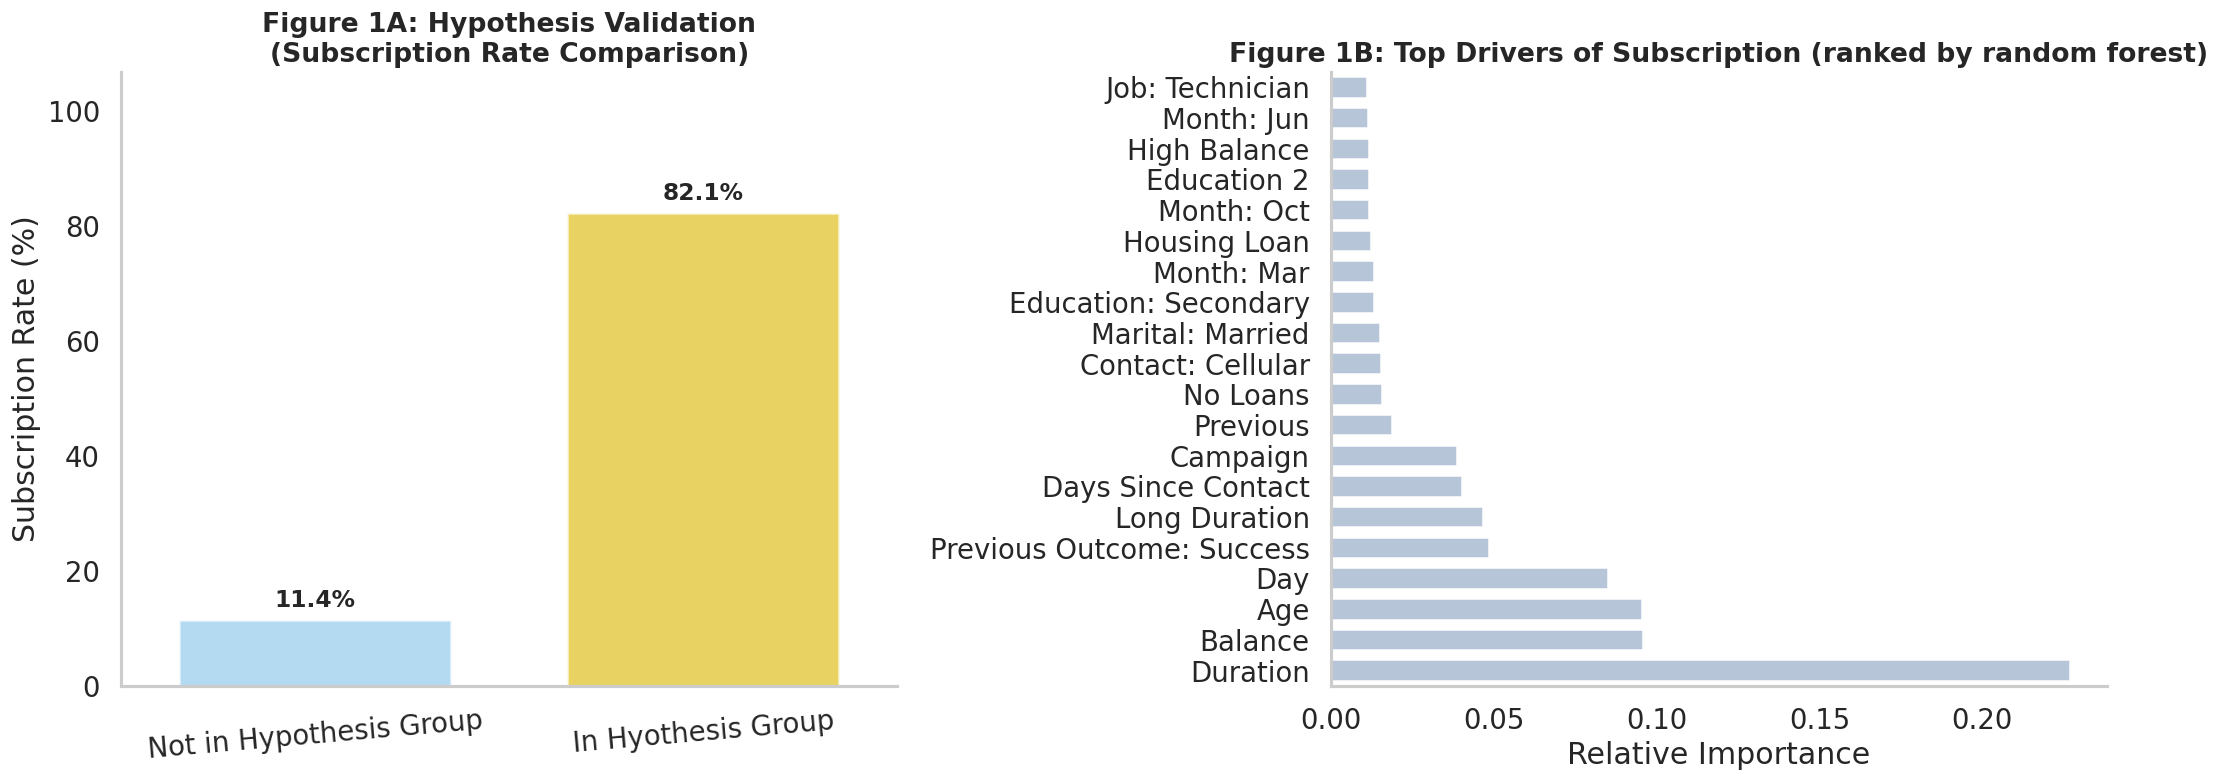

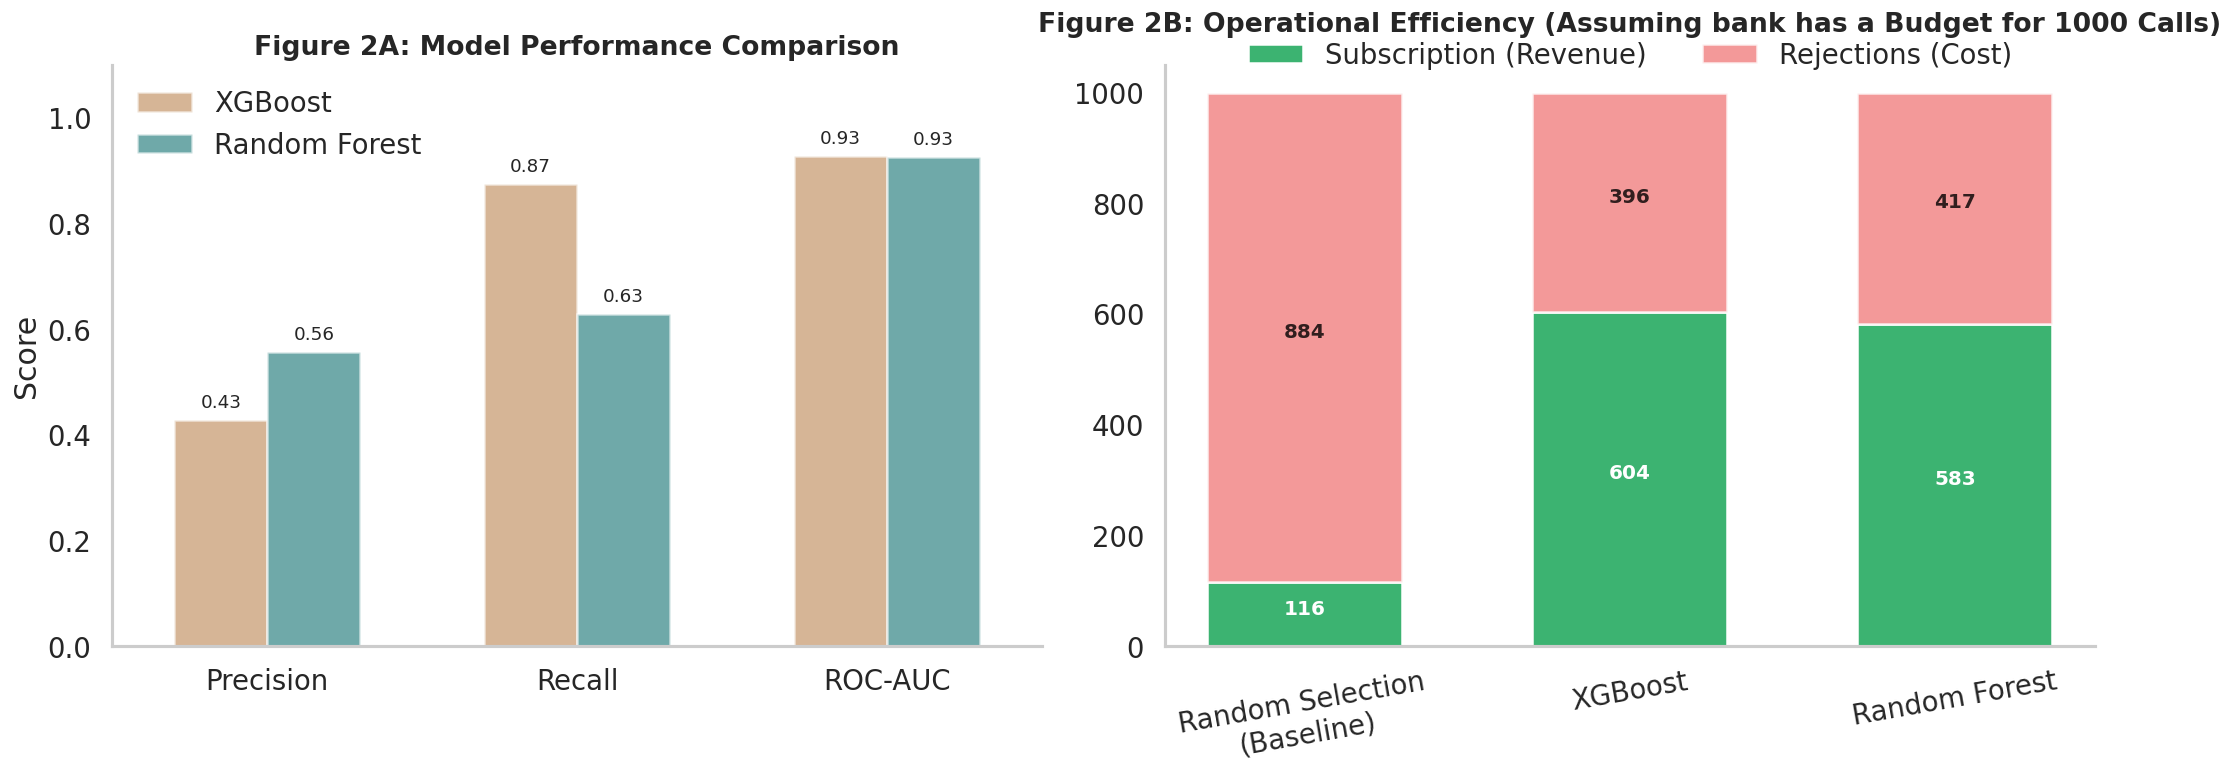

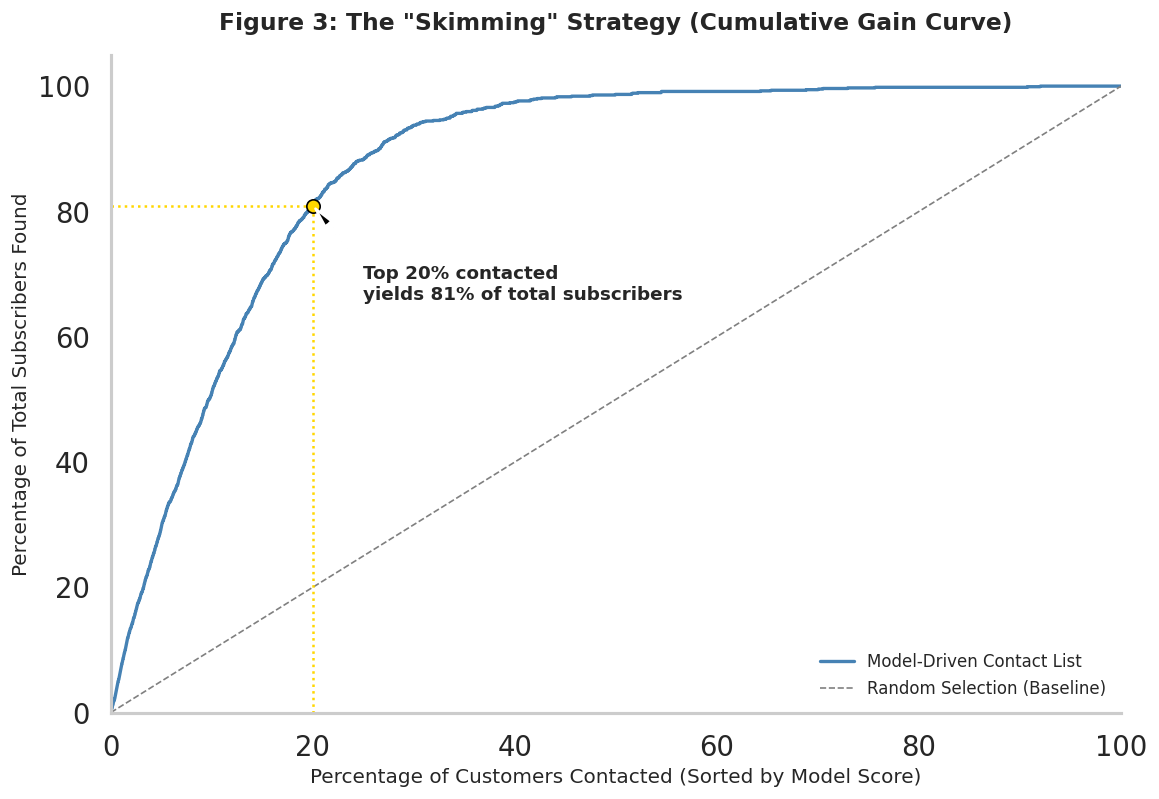

In [ ]:


def clean_names(name_list):
    """
    Removes prefixes like 'scaler__', 'onehot__', 'remainder__' and formats text,
    replacing encoded numeric labels with clear descriptive text.
    """
    clean = []
    for name in name_list:
        # Save original name for specific checks later
        original_name = name

        # 1. Remove prefix
        if '__' in name:
            name = name.split('__')[1]

        # 2. Specific Label Replacements (Fixing Encoded Values)

        # If the feature name value is '3' (from poutcome: {'success': 3})
        if '3' in name:
            name = 'Previous outcome: success'

        # If the feature name value is '2' (could be marital or contact)
        if '2' in name:
            # Check if the original name came from 'contact' (contact__2)
            if 'contact' in original_name:
                name = 'contact: cellular'
            # Check if the original name came from 'marital' (marital__2)
            elif 'marital' in original_name:
                name = 'marital: married'
        if "1" in name:
          name = "Education: Secondary"

        # 3. General formatting and renaming
        name = name.replace('_', ' ').title()

        # Add category prefixes and perform general text cleanup
        name = name.replace('Job ', 'Job: ')
        name = name.replace('Month ', 'Month: ')
        name = name.replace('Pdays', 'Days Since Contact')
        name = name.replace('Hypothesis Group', 'High-Potential Profile')

        # 4. Final label cleanup based on replacements above

        # Fix 'Prev Outcome: Success'
        name = name.replace('Poutcome Success', 'Prev Outcome: Success')

        # Fix 'Marital: Other'
        name = name.replace('Marital Other', 'Marital: Other')

        # Fix 'Contact: Cellular'
        name = name.replace('Contact Cellular', 'Contact: Cellular')

        # Fallback for generic 'Poutcome' prefix (used for Poutcome: Unknown, Failure, Other)
        name = name.replace('Poutcome ', 'Prev Outcome: ')

        clean.append(name)

    return clean

# Set professional style (keeping the nice defaults, but adding explicit parameters)
sns.set_theme(style="whitegrid", context="talk") # Changed to whitegrid for better structure
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
def create_storytelling_plots(rf_model, xgb_model, X_test_rf, X_test_xgb, y_test, importances_df, X_train_raw, y_train_raw, df_full):

    # --- FIGURE 1: THE "WHY" (Hypothesis & Drivers) ---
    fig1, axes1 = plt.subplots(1, 2, figsize=(18, 7))

    # 1A. Hypothesis Validation (Bar distance minimized, using df_full)
    target_col = 'y' if 'y' in df_full.columns else 'target'
    hyp_col = [c for c in df_full.columns if 'hypothesis' in c.lower()]

    if hyp_col:
        target_values = df_full[target_col].map({'yes': 1, 'no': 0}) if df_full[target_col].dtype == 'object' else df_full[target_col]

        data_for_hyp = pd.DataFrame({'Group': df_full[hyp_col[0]], 'Target': target_values})
        rates = data_for_hyp.groupby('Group')['Target'].mean() * 100

        hyp_data = pd.DataFrame({
            'Group': ['Not in Hypothesis Group', 'In Hyothesis Group'],
            'Rate': [rates.get(0, 0), rates.get(1, 0)]
        })

        # Plotting with minimized bar distance (width=0.7)
        sns.barplot(x='Group', y='Rate', data=hyp_data, ax=axes1[0],
                           palette=['#87CEFA', '#FFD700'],
                           width=0.7, alpha = 0.7)

        axes1[0].set_title("Figure 1A: Hypothesis Validation\n(Subscription Rate Comparison)", fontweight='bold', fontsize=16)
        axes1[0].set_ylabel("Subscription Rate (%)")
        axes1[0].set_xlabel("")
        axes1[0].set_ylim(0, rates.max() * 1.3)
        axes1[0].tick_params(axis='x', rotation=5)

        # Aesthetic Cleanup: Remove top/right spine and grid
        axes1[0].spines['top'].set_visible(False)
        axes1[0].spines['right'].set_visible(False)
        axes1[0].grid(False)

        # Label bars
        for container in axes1[0].containers:
            axes1[0].bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold', fontsize=14)

    # 1B. Top 15 Drivers (Feature Importance) - Single Neutral Color
    top_N = 20
    # importances_df = importances_df[importances_df['feature'] != 'remainder__duration_log	'].copy()
    top_N_df = importances_df.head(top_N).copy()
    top_N_df['Clean_Name'] = clean_names(top_N_df['feature'])

    # Reverse order for better visualization (highest on top)
    top_N_df = top_N_df.iloc[::-1]

    # Use a single, neutral color (e.g., Light Steel Blue)
    NEUTRAL_COLOR = '#B0C4DE'

    sns.barplot(x='importance', y='Clean_Name', data=top_N_df, ax=axes1[1],
                color=NEUTRAL_COLOR, # Use single color instead of palette
                width=0.7)

    axes1[1].set_title(f"Figure 1B: Top Drivers of Subscription (ranked by random forest)", fontweight='bold', fontsize=16)
    axes1[1].set_xlabel("Relative Importance")
    axes1[1].set_ylabel("")

    # Legend removed as requested (no color classification)

    # Aesthetic Cleanup: Remove top/right spine and grid
    axes1[1].spines['top'].set_visible(False)
    axes1[1].spines['right'].set_visible(False)
    axes1[1].grid(False)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig1.savefig(input_directory + 'Figure_1_Campaign_Drivers.png', bbox_inches='tight', dpi=300) # ADD THIS LINE
    plt.show()

    # ==========================================================================
    # --- FIGURE 2: THE "CHOICE" (Metrics & Efficiency) ---
    # ==========================================================================
    fig2, axes2 = plt.subplots(1, 2, figsize=(18, 7))

    # Resetting index once for Figures 2 and 3 to ensure alignment
    X_test_rf_aligned = X_test_rf.reset_index(drop=True)
    X_test_xgb_aligned = X_test_xgb.reset_index(drop=True)
    y_test_aligned = y_test.reset_index(drop=True)

    # 2A. Metrics Comparison
    metrics = []
    for name, (model, X_dat) in {'XGBoost': (xgb_model, X_test_xgb_aligned), 'Random Forest': (rf_model, X_test_rf_aligned)}.items():
        preds = model.predict(X_dat)
        probs = model.predict_proba(X_dat)[:, 1]
        metrics.extend([
            {'Model': name, 'Metric': 'Precision', 'Score': precision_score(y_test_aligned, preds)},
            {'Model': name, 'Metric': 'Recall', 'Score': recall_score(y_test_aligned, preds)},
            {'Model': name, 'Metric': 'ROC-AUC', 'Score': roc_auc_score(y_test_aligned, probs)}
        ])

    metrics_df = pd.DataFrame(metrics)
    sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df, ax=axes2[0],
                palette=['#CD853F', '#008080'],
                width=0.6, alpha = 0.6)

    axes2[0].set_title("Figure 2A: Model Performance Comparison", fontweight='bold', fontsize=16)
    axes2[0].legend(loc='upper left', frameon=False, ncol=1)
    axes2[0].set_ylim(0, 1.1)
    axes2[0].set_xlabel('')  # This removes the x-axis label text

    # Aesthetic Cleanup: Remove top/right spine and grid
    axes2[0].spines['top'].set_visible(False)
    axes2[0].spines['right'].set_visible(False)
    axes2[0].grid(False)

    for container in axes2[0].containers:
        axes2[0].bar_label(container, fmt='%.2f', padding=5, fontsize=11)

    # 2B. Operational Efficiency (1000 Calls) - Legend repositioned
    budget = 1000

    random_selection_success = int(budget * y_test_aligned.mean())
    names, successes, wasted = ['Random Selection\n(Baseline)'], [random_selection_success], [budget - random_selection_success]

    for name, (model, X_dat) in {'XGBoost': (xgb_model, X_test_xgb_aligned), 'Random Forest': (rf_model, X_test_rf_aligned)}.items():
        probs = model.predict_proba(X_dat)[:, 1]

        hits = pd.DataFrame({'y': y_test_aligned, 'p': probs}).sort_values('p', ascending=False).head(budget)['y'].sum()
        names.append(name)
        successes.append(hits)
        wasted.append(budget - hits)

    x_pos = np.arange(len(names))
    axes2[1].bar(x_pos, successes, label='Subscription (Revenue)', color='#3CB371', width=0.6)
    axes2[1].bar(x_pos, wasted, bottom=successes, label='Rejections (Cost)', color='#F08080', alpha=0.8, width=0.6)

    axes2[1].set_xticks(x_pos)
    axes2[1].set_xticklabels(names, rotation=10)
    axes2[1].set_title(f"Figure 2B: Operational Efficiency (Assuming bank has a Budget for {budget} Calls)", fontweight='bold', fontsize=16, pad = 20)

    # Legend repositioned well above the bars
    axes2[1].legend(loc='lower center', bbox_to_anchor=(0.5, 0.95), ncol=2, frameon=False)
    # Aesthetic Cleanup: Remove top/right spine and grid
    axes2[1].spines['top'].set_visible(False)
    axes2[1].spines['right'].set_visible(False)
    axes2[1].grid(False)

    for i, s in enumerate(successes):
        axes2[1].text(i, s/2, f"{s}", ha='center', color='white', fontweight='bold', fontsize=12)
        axes2[1].text(i, s + wasted[i]/2, f"{wasted[i]}", ha='center', color='black', alpha=0.8, fontweight='bold', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig2.savefig(input_directory + 'Figure_2_Model_Impact.png', bbox_inches='tight', dpi=300) # ADD THIS LINE
    plt.show()

    # ==========================================================================
    # --- FIGURE 3: THE "STRATEGY" (Skimming Strategy) ---
    # ==========================================================================
    fig3, ax3 = plt.subplots(figsize=(10, 7))

    rf_probs = rf_model.predict_proba(X_test_rf_aligned)[:, 1]

    df_gain = pd.DataFrame({'y': y_test_aligned, 'p': rf_probs}).sort_values('p', ascending=False)
    cum_gain = np.cumsum(df_gain['y'].values) / df_gain['y'].sum() * 100

    # Line width reduced as requested

    ax3.plot(np.linspace(0, 100, len(cum_gain)), cum_gain, color='#4682B4', linewidth=2, label='Model-Driven Contact List')

    ax3.plot([0, 100], [0, 100], color='grey', linestyle='--', linewidth=1, label='Random Selection (Baseline)')

    # Gold Tier Highlight
    idx_20 = int(len(cum_gain) * 0.20)
    val_20 = cum_gain[idx_20]
    ax3.plot([20, 20], [0, val_20], color='#FFD700', linestyle=':', linewidth=1.5)
    ax3.plot([0, 20], [val_20, val_20], color='#FFD700', linestyle=':', linewidth=1.5)
    ax3.plot(20, val_20, 'o', color='#FFD700', markersize=8, markeredgecolor='black')

    ax3.annotate(f'Top 20% contacted\nyields {val_20:.0f}% of total subscribers',
             xy=(20, val_20), xytext=(25, val_20 - 15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=11, fontweight='bold')

    ax3.set_title('Figure 3: The "Skimming" Strategy (Cumulative Gain Curve)', fontweight='bold', fontsize=14, pad=15)
    ax3.set_xlabel('Percentage of Customers Contacted (Sorted by Model Score)', fontsize = 12)
    ax3.set_ylabel('Percentage of Total Subscribers Found', fontsize = 12)
    ax3.set_xlim(0, 100)
    ax3.set_ylim(0, 105)
    ax3.legend(loc='lower right', frameon=False, fontsize = 10)

    # Aesthetic Cleanup: Gridlines ON (as requested for possibly the last)
    ax3.grid(False)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    plt.tight_layout()
    fig3.savefig(input_directory + 'Figure_3_Skimming_Strategy.png', bbox_inches='tight', dpi=300) # ADD THIS LINE
    plt.show()
# ==============================================================================
# MAIN EXECUTION

# 3. Create Plots



create_storytelling_plots(
    rf_model,
    xgb_model,
    X_test_full[feats_rf30],
    X_test_full[feats_variance],
    y_test,
    importances,
    X_train_full,
    y_train,
    df
)